In [16]:
import os
import pickle
import re
import pprint
import numpy as np
import sympy as sp
import openturns as ot
# Display the final graph
import openturns.viewer as viewer
import matplotlib.pyplot as plt
import trimesh as tr
from importlib import reload
from functools import partial

from math import pi
from joblib import Parallel, delayed
from importlib import reload
from IPython.display import display, clear_output
from time import time
from sympy.printing import latex
from trimesh import viewer as trview
import sklearn

from scipy.optimize import OptimizeResult, minimize, basinhopping, \
                           differential_evolution, brute, shgo, check_grad, \
                           approx_fprime, fsolve, NonlinearConstraint, Bounds, approx_fprime

import tqdm
import otaf
import torch

from gldpy import GLD

ot.Log.Show(ot.Log.NONE)
np.set_printoptions(suppress=True)
ar = np.array

# **Dans ce Notebook, on analysera le système simple hyperstatique 2D en utlisant la méthode basée sur une représentation matricielle du mécanisme, version automatique.** 

#### **Définition des grandeurs nominales de la pièce**

In [2]:
hM = 10
hF = 10.2
L1 = 30
L2 = 70
L3 = L1
lM = 10
lF = 10.2

#### **Définition du repère global R0 / qui est aussi un repère local de la pièce fixe.**

#### **Définisson les coordonnées des points charactéristiques de chaque surface de chaque pièce.**

In [3]:
# Pièce 1 (male)
P1A0, P1A1, P1A2 = (
    ar((L1 - lM / 2, hM / 2, 0.0)),
    ar((L1 - lM / 2, 0, 0.0)),
    ar((L1 - lM / 2, hM, 0.0)),
)
P1B0, P1B1, P1B2 = (
    ar((L1 + lM / 2, hM / 2, 0.0)),
    ar((L1 + lM / 2, 0, 0.0)),
    ar((L1 + lM / 2, hM, 0.0)),
)
P1C0, P1C1, P1C2 = (
    ar((L1 + L2 - lM / 2, hM / 2, 0.0)),
    ar((L1 + L2 - lM / 2, 0, 0.0)),
    ar((L1 + L2 - lM / 2, hM, 0.0)),
)
P1D0, P1D1, P1D2 = (
    ar((L1 + L2 + lM / 2, hM / 2, 0.0)),
    ar((L1 + L2 + lM / 2, 0, 0.0)),
    ar((L1 + L2 + lM / 2, hM, 0.0)),
)
P1E0, P1E1 = ar((0.0, 0.0, 0.0)), ar((L1 + L2 + L3, 0.0, 0.0))

# Pièce 2 (femelle)  # On met les points à hM et pas hF pour qu'ils soient bien oposées! (Besoin??)
P2A0, P2A1, P2A2 = (
    ar((L1 - lF / 2, hF / 2, 0.0)),
    ar((L1 - lF / 2, 0, 0.0)),
    ar((L1 - lF / 2, hF, 0.0)),
)
P2B0, P2B1, P2B2 = (
    ar((L1 + lF / 2, hF / 2, 0.0)),
    ar((L1 + lF / 2, 0, 0.0)),
    ar((L1 + lF / 2, hF, 0.0)),
)
P2C0, P2C1, P2C2 = (
    ar((L1 + L2 - lF / 2, hF / 2, 0.0)),
    ar((L1 + L2 - lF / 2, 0, 0.0)),
    ar((L1 + L2 - lF / 2, hF, 0.0)),
)
P2D0, P2D1, P2D2 = (
    ar((L1 + L2 + lF / 2, hF / 2, 0.0)),
    ar((L1 + L2 + lF / 2, 0, 0.0)),
    ar((L1 + L2 + lF / 2, hF, 0.0)),
)
P2E0, P2E1 = ar((0.0, 0.0, 0.0)), ar((L1 + L2 + L3, 0.0, 0.0))

#### **Définisson les repères locaux de chaque surface substituée.**

In [4]:
R0 = ar([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
x_, y_, z_ = R0[0], R0[1], R0[2]

# Pièce1
RP1b = RP1d = R0
RP1a = RP1c = ar([-x_, -y_, z_]).T
RP1e = ar([y_, -x_, z_]).T

# Pièce2
RP2a = RP2c = R0
RP2b = RP2d = ar([-x_, -y_, z_]).T
RP2e = ar([-y_, x_, z_]).T

#### Maintenant construisons les matrices de transformation pour passer du repère global aux repères locaux (et de définition des matrices de déviation et Jeu! )

In [5]:
TP1cC0, TP1cC1, TP1cC2 = (
    otaf.geometry.tfrt(RP1c, P1C0),
    otaf.geometry.tfrt(RP1c, P1C1),
    otaf.geometry.tfrt(RP1c, P1C2),
)
TP1aA0, TP1aA1, TP1aA2 = (
    otaf.geometry.tfrt(RP1a, P1A0),
    otaf.geometry.tfrt(RP1a, P1A1),
    otaf.geometry.tfrt(RP1a, P1A2),
)
TP1bB0, TP1bB1, TP1bB2 = (
    otaf.geometry.tfrt(RP1b, P1B0),
    otaf.geometry.tfrt(RP1b, P1B1),
    otaf.geometry.tfrt(RP1b, P1B2),
)
TP1dD0, TP1dD1, TP1dD2 = (
    otaf.geometry.tfrt(RP1d, P1D0),
    otaf.geometry.tfrt(RP1d, P1D1),
    otaf.geometry.tfrt(RP1d, P1D2),
)
TP1eE0, TP1eE1 = otaf.geometry.tfrt(RP1e, P1E0), otaf.geometry.tfrt(RP1e, P1E1)
TP2aA0, TP2aA1, TP2aA2 = (
    otaf.geometry.tfrt(RP2a, P2A0),
    otaf.geometry.tfrt(RP2a, P2A1),
    otaf.geometry.tfrt(RP2a, P2A2),
)
TP2cC0, TP2cC1, TP2cC2 = (
    otaf.geometry.tfrt(RP2c, P2C0),
    otaf.geometry.tfrt(RP2c, P2C1),
    otaf.geometry.tfrt(RP2c, P2C2),
)
TP2bB0, TP2bB1, TP2bB2 = (
    otaf.geometry.tfrt(RP2b, P2B0),
    otaf.geometry.tfrt(RP2b, P2B1),
    otaf.geometry.tfrt(RP2b, P2B2),
)
TP2dD0, TP2dD1, TP2dD2 = (
    otaf.geometry.tfrt(RP2d, P2D0),
    otaf.geometry.tfrt(RP2d, P2D1),
    otaf.geometry.tfrt(RP2d, P2D2),
)
TP2eE0, TP2eE1 = otaf.geometry.tfrt(RP2e, P2E0), otaf.geometry.tfrt(RP2e, P2E1)

In [6]:
system_data = {
    "PARTS": {
        "1": {
            "a": {
                "FRAME": RP1a,
                "TYPE": "plane",
                "CONSTRAINTS_D": ["NONE"],
                "POINTS": {"A0": P1A0, "A1": P1A1, "A2": P1A2},
                "INTERACTIONS": ["P2a"],
                "CONSTRAINTS_G": ["FLOATING"],
            },
            "b": {
                "FRAME": RP1b,
                "TYPE": "plane",
                "CONSTRAINTS_D": ["NONE"],
                "POINTS": {"B0": P1B0, "B1": P1B1, "B2": P1B2},
                "INTERACTIONS": ["P2b"],
                "CONSTRAINTS_G": ["FLOATING"],
            },
            "c": {
                "FRAME": RP1c,
                "TYPE": "plane",
                "CONSTRAINTS_D": ["NONE"],
                "POINTS": {"C0": P1C0, "C1": P1C1, "C2": P1C2},
                "INTERACTIONS": ["P2c"],
                "CONSTRAINTS_G": ["FLOATING"],
            },
            "d": {
                "FRAME": RP1d,
                "TYPE": "plane",
                "CONSTRAINTS_D": ["NONE"],
                "POINTS": {"D0": P1D0, "D1": P1D1, "D2": P1D2},
                "INTERACTIONS": ["P2d"],
                "CONSTRAINTS_G": ["FLOATING"],
            },
            "e": {
                "FRAME": RP1e,
                "TYPE": "plane",
                "CONSTRAINTS_D": ["PERFECT"],
                "POINTS": {"E0": P1E0, "E1": P1E1},
                "INTERACTIONS": ["P2e"],
                "CONSTRAINTS_G": ["SLIDING"],
            },
        },
        "2": {
            "a": {
                "FRAME": RP2a,
                "TYPE": "plane",
                "CONSTRAINTS_D": ["NONE"],
                "POINTS": {"A0": P2A0, "A1": P2A1, "A2": P2A2},
                "INTERACTIONS": ["P1a"],
                "CONSTRAINTS_G": ["FLOATING"],
            },
            "b": {
                "FRAME": RP2b,
                "TYPE": "plane",
                "CONSTRAINTS_D": ["NONE"],
                "POINTS": {"B0": P2B0, "B1": P2B1, "B2": P2B2},
                "INTERACTIONS": ["P1b"],
                "CONSTRAINTS_G": ["FLOATING"],
            },
            "c": {
                "FRAME": RP2c,
                "TYPE": "plane",
                "CONSTRAINTS_D": ["NONE"],
                "POINTS": {"C0": P2C0, "C1": P2C1, "C2": P2C2},
                "INTERACTIONS": ["P1c"],
                "CONSTRAINTS_G": ["FLOATING"],
            },
            "d": {
                "FRAME": RP2d,
                "TYPE": "plane",
                "CONSTRAINTS_D": ["NONE"],
                "POINTS": {"D0": P2D0, "D1": P2D1, "D2": P2D2},
                "INTERACTIONS": ["P1d"],
                "CONSTRAINTS_G": ["FLOATING"],
            },
            "e": {
                "FRAME": RP2e,
                "TYPE": "plane",
                "CONSTRAINTS_D": ["PERFECT"],
                "POINTS": {"E0": P2E0, "E1": P2E1},
                "INTERACTIONS": ["P1e"],
                "CONSTRAINTS_G": ["SLIDING"],
            },
        },
    },
    "LOOPS": {
        "COMPATIBILITY": {
            "L0": "P1eE0 -> P2eE0 -> P2aA0 -> P1aA0",
            "L1": "P1eE0 -> P2eE0 -> P2dD0 -> P1dD0",
            "L2": "P1cC0 -> P2cC0 -> P2bB0 -> P1bB0",
            "L3": "P1bB0 -> P2bB0 -> P2aA0 -> P1aA0",
        },
    },
    "GLOBAL_CONSTRAINTS": "2D_NZ",
}

In [7]:
ADP =otaf.AssemblyDataProcessor(system_data)
ADP.generate_expanded_loops()

In [8]:
ADP.get_notebook_scene_sphere_clouds()

In [9]:
CLH = otaf.CompatibilityLoopHandling(ADP)
compatibility_expressions = CLH.get_compatibility_expression_from_FO_matrices()

In [10]:
ILH = otaf.InterfaceLoopHandling(ADP, CLH) #circle_resolution=CIRCLE_RESOLUTION
interface_constraints = ILH.get_interface_loop_expressions()

In [11]:
SOCAM = otaf.SystemOfConstraintsAssemblyModel(
    compatibility_expressions, interface_constraints
)
SOCAM.embedOptimizationVariable()

# Estimation de la probabilité de défaillance par Monte-Carlo

Les codes permettant de simuler le système mécanique ayant été définis, nous allons valider leur fonctionalité en éffectuant une étude similaire au notebook "Analyse_Preli_Trou_Carre_2D", et en comparant les résultats. 

Commencons d'abord en définissant les tolérances et en calculant leur effet sur la variance des différents défauts élémentaires. 

Ensuite nous pourrons créer le plan d'experience, en y introduisant aussi l'imprécision par l'intermédaire d'un coefficient d'allocation du défaut. 

In [12]:
tol = 0.1 * np.sqrt(2)
Cm = 1  # Process capability
sigma_e_pos = tol / (6 * Cm)
theta_max_m = tol / hM
theta_max_f = tol / hF

sigma_e_theta_m = (2 * theta_max_m) / (6 * Cm)
sigma_e_theta_f = (2 * theta_max_f) / (6 * Cm)

SIZE_MC = int(1e3)

In [21]:
# Construction of the random vector of sigma_max 
# Samples directmy generated by this distribution do not respect the feature level 
# frequentist constraint, and have thus to be scaled by lambda.
RandDeviationVect = otaf.distribution.get_composed_normal_defect_distribution(
    defect_names=SOCAM.deviation_symbols,
    sigma_dict = {"gamma_d_2":sigma_e_theta_f, 
                  "gamma_d_3":sigma_e_theta_m,
                  "gamma_d_4":sigma_e_theta_f,
                  "gamma_d_5":sigma_e_theta_m,
                  "gamma_d_6":sigma_e_theta_m,
                  "gamma_d_7":sigma_e_theta_f,
                  "gamma_d_8":sigma_e_theta_f,
                  "gamma_d_9":sigma_e_theta_m,
                  "u":sigma_e_pos})
NDim_Defects = int(RandDeviationVect.getDimension())

## Construction d'un métamodèle basé sur un réseau de neurones. 

In [14]:
# Construction de l'échantillon d'entrainement
# Define the seed, sample size, and file paths
SEED = 420  # Example seed value
sample_size = 100000

# Ensure reproducibility by setting the seed
np.random.seed(SEED)

# Generate the sample
dist = otaf.distribution.multiply_composed_distribution_with_constant(
    RandDeviationVect, 1.25) # We now work with low failure probabilities so we increase the dispresion to have more failed parts for the training
#TRAIN_SAMPLE = np.array(otaf.uncertainty.generateLHSExperiment(dist, sample_size))
TRAIN_SAMPLE = np.array(dist.getSample(sample_size),dtype="float32")
# Compute the results
TRAIN_RESULTS = otaf.uncertainty.compute_gap_optimizations_on_sample_batch(
    SOCAM,
    TRAIN_SAMPLE,
    bounds=None,
    n_cpu=-2,
    progress_bar=True,
    batch_size=500,
    dtype="float32"
)

# Assign X and y from TRAIN_SAMPLE and TRAIN_RESULTS
Xtrain = TRAIN_SAMPLE
ytrain = TRAIN_RESULTS
print(f"Ratio of failed simulations in sample : {np.where(ytrain[:,-1]<0,1,0).sum()/sample_size}")

  0%|          | 0/100000 [00:00<?, ?it/s]

Ratio of failed simulations in sample : 0.09241


[16, 85, 42, 14, 1]


  0%|          | 0/2 [00:00<?, ?batch/s]

Epoch 001, Val Loss: 0.953672, Val R2: -714.230591


  0%|          | 0/2 [00:00<?, ?batch/s]

Epoch 002, Val Loss: 0.883885, Val R2: -123.030296


...

Epoch 498, Val Loss: 0.000891, Val R2: 0.999112


  0%|          | 0/2 [00:00<?, ?batch/s]

Epoch 499, Val Loss: 0.000896, Val R2: 0.999105


  0%|          | 0/2 [00:00<?, ?batch/s]

Epoch 500, Val Loss: 0.000930, Val R2: 0.999070
Finished training at epoch 500 with best loss 0.000891 and R2 of 0.999112


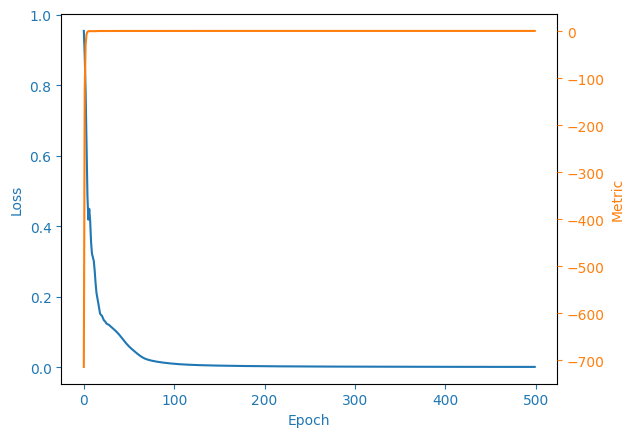

In [17]:
dim = int(RandDeviationVect.getDimension())
neural_model = otaf.surrogate.NeuralRegressorNetwork(
    dim, 1,
    Xtrain, ytrain[:,-1], 
    clamping=True, 
    finish_critertion_epoch=5,
    loss_finish=1e-6, 
    metric_finish=0.99999, 
    max_epochs=500, 
    batch_size=30000, 
    compile_model=False, 
    train_size=0.6, 
    input_description=RandDeviationVect.getDescription(),
    display_progress_disable=False)

lr=0.003

#neural_model.model = KAN([dim, 8, 4, 1])  #otaf.surrogate.get_base_relu_mlp_model(dim, 1, False)

neural_model.model = torch.nn.Sequential(
    *otaf.surrogate.get_custom_mlp_layers([dim, 100, 70, 30, 1], activation_class=torch.nn.GELU)
)

neural_model.optimizer = torch.optim.AdamW(neural_model.parameters(), lr=lr, weight_decay=1e-4)
otaf.surrogate.initialize_model_weights(neural_model)
neural_model.scheduler =  torch.optim.lr_scheduler.ExponentialLR(neural_model.optimizer, 1.0001)
neural_model.loss_fn = torch.nn.MSELoss()
#neural_model.loss_fn = otaf.uncertainty.LimitSpaceFocusedLoss(0.0001, 2, square=True) # otaf.uncertainty.PositiveLimitSpaceFocusedLoss(0.0001, 2, 4, square=False)


neural_model.train_model()
neural_model.plot_results()

### Analyse  des tolérances imprécise avec recherche de l'intervale sur la probabilité de défaillance. 

In [22]:
#Function to store results

result_dict={}

def store_results(x, fp_gld, fp_slack, gld_params, experiment_key=None, result_dict=result_dict):
    x_key = otaf.common.bidirectional_string_to_array_conversion(x)
    x_dict = {"FP_GLD": fp_gld, "FP_SLACK":fp_slack, "GLD_PARAMS": gld_params}
    if experiment_key is None:
        if x_key in result_dict.keys():
            result_dict[x_key].update(x_dict)
        else :
            result_dict[x_key] = x_dict
    else : 
        if experiment_key not in result_dict:
            result_dict[experiment_key] = {}
        if x_key in result_dict[experiment_key].keys():
            result_dict[experiment_key][x_key].update(x_dict)
        else:
            result_dict[experiment_key][x_key] = x_dict

In [23]:
SIZE_MC_PF = 250000 #int(1e6) #1e4

sample_gld = otaf.sampling.generate_and_transform_sequence(NDim_Defects, SIZE_MC_PF, RandDeviationVect) 
scale_factor = 1.0

# Generalized lambda distribution object for fitting
gld = GLD('VSL')

def model(x, sample=sample_gld):
    # Direct model without ai
    x = sample * x[np.newaxis, :]
    gap_variable_array = otaf.uncertainty.compute_gap_optimizations_on_sample_batch(
        SOCAM, x, n_cpu=-1, progress_bar=True
    )
    slack_variable = gap_variable_array[:, -1]
    return slack_variable

def model2(x, sample=sample_gld): 
    # Surrogate ai model
    x = sample * x[np.newaxis, :]
    return np.squeeze(neural_model.evaluate_model_non_standard_space(x).detach().numpy())

@otaf.optimization.scaling(scale_factor)
def optimization_function_mini(x, failure_slack=0.0, model=model2, experiment_key=None, result_dict=result_dict):
    # Here we search the minimal probability of failure
    slack = model(x)
    gld_params = gld.fit_LMM(slack,  disp_fit=False, disp_optimizer=False)
    fp_slack = np.where(slack<failure_slack,1,0).mean()
    fp_gld = np.nan
    if np.any(np.isnan(gld_params)):
        fp_out = fp_slack
    else :
        #print("\tgld_params:", gld_params)
        fp_gld = gld.CDF_num(failure_slack, gld_params)
        fp_out = fp_gld
    
    store_results(x, fp_gld, fp_slack, gld_params, experiment_key, result_dict)
    return fp_out


@otaf.optimization.scaling(scale_factor)
def optimization_function_maxi(x, failure_slack=0.0, model=model2, experiment_key=None, result_dict=result_dict):
    # Here we search the maximal probability of failure so negative output
    slack = model(x)
    gld_params = gld.fit_LMM(slack, disp_fit=False, disp_optimizer=False)
    fp_slack = np.where(slack<failure_slack,1,0).mean()
    fp_gld = np.nan
    if np.any(np.isnan(gld_params)):
        fp_out = fp_slack
    else :
        #print("\tgld_params:", gld_params)
        fp_gld = gld.CDF_num(failure_slack, gld_params)
        fp_out = fp_gld
    
    store_results(x, fp_gld, fp_slack, gld_params, experiment_key, result_dict)

    return fp_out*-1

# Definition of the FLDPCF constraint function

Variance (std) based parameter constraint function

In [25]:
midof_funcs = otaf.tolerances.MiSdofToleranceZones()

feature_constraint_list = []

# We iterate over the symbols (which are in order), get the index and then 
# the deviation matrix object, and then we can know the part ID and so its height
for var_id in set(otaf.sampling.validate_and_extract_indices(SOCAM.deviation_symbols)):
    dev_mat = CLH.get_deviation_matrix_by_id(var_id)[0]
    out = otaf.constants.D_MATRIX_PATTERN1.match(dev_mat.name)    
    part_id = out.groups()[1]
    if part_id == 2 : #part is female so taller
        h = hF
    else :
        h = hM
    
    fconst = otaf.tolerances.FeatureLevelStatisticalConstraint(
        midof_funcs.two_parallel_straight_lines,
        mif_args = (tol, h),
        n_dof = 2,
        n_sample = 80000,
        target = "std", #"prob",
        target_val = sigma_e_pos*np.sqrt(1-(2/np.pi)), #To be folded normal variance! # Not ideal yet
        isNormal = True, #The component distributions are normal
        normalizeOutput = True, #Normalize constraint
    )
    feature_constraint_list.append(fconst)

# The input of this object would be a list of parameters (their real value)
composed_assembly_constraint = otaf.tolerances.ComposedAssemblyLevelStatisticalConstraint(feature_constraint_list)

In [26]:
param_bounds_one_feature_f = [[0.0,0.0], [0.0, sigma_e_pos], #u, mean std
                            [0.0,0.0], [0.0, sigma_e_theta_f], #gamma, mean std
                           ]
param_bounds_one_feature_m = [[0.0,0.0], [0.0, sigma_e_pos], #u, mean std
                            [0.0,0.0], [0.0, sigma_e_theta_m], #gamma, mean std
                           ]

param_bounds = [param_bounds_one_feature_f,
                param_bounds_one_feature_m,
                param_bounds_one_feature_f,
                param_bounds_one_feature_m,
                param_bounds_one_feature_m,
                param_bounds_one_feature_f,
                param_bounds_one_feature_f,
                param_bounds_one_feature_m]

# The input of this object is a list of normalized parameters (between 0 and 1)
normalized_assembly_constraint = otaf.tolerances.NormalizedAssemblyLevelConstraint(
    composed_assembly_constraint,
    param_val_bounds=param_bounds)

#### The assembly constraint takes as an input the list of list of paramters for all the features. But as the distriutions (normals) are suppposed to be centered, we only need to have the standard deviations as inputs so we construct a little intermediary class that takes as an input only the standard deviations and not the means, and completes the means with 0 to pass it to the assembly constraint. 

In [27]:
def assembly_constraint_no_mean(x, scale_factor=1.0, result_dict=result_dict, experiment_key=None):
    """ The functions takes directly the concatenated list of all normalized parameters, and reconstructs the right object.
    There should be 32 variables for the standard deviations, we just add the mean values in the vector so the input is correct 
    for the constraint object
    """
    assert len(x)==16, "problem with input."
    zer = np.zeros(2) # These are the mean values (all 0)
    pl = np.array(x)
    params_for_assembly = []
    for i in range(8):
        params = x[i*2:i*2+2]
        pa = [item for pair in zip(zer, params) for item in pair]
        params_for_assembly.append(pa)
    constraint_array =  normalized_assembly_constraint(params_for_assembly)
    
    # Storing data
    x_key = otaf.common.bidirectional_string_to_array_conversion(x)
    data = {"CONST":constraint_array}
    if experiment_key is not None:
        if x_key in result_dict[experiment_key].keys():
            result_dict[experiment_key][x_key].update(data)
        else:
            result_dict[experiment_key][x_key] = data
    else :
        if x_key in result_dict.keys():
            result_dict[x_key].update(data)
        else :
            result_dict[x_key] = data

    return constraint_array * scale_factor

In [28]:
# Define the nonlinear constraint with the updated vector-valued function and Jacobian
nonLinearConstraint = lambda resDict, expKey : NonlinearConstraint(
    fun = lambda x : assembly_constraint_no_mean(x, 1.0, resDict, expKey),
    lb  = -0.005 * np.ones((8,)),
    ub  = 0.005 * np.ones((8,)),
    keep_feasible=True,
)

In [31]:
def pf_min_max_optimizer(failure_slack=0.0, result_dict=result_dict, experiment_key=None):
    # Initial guess
    x0 = [0.5] * NDim_Defects  # Initial guess
    
    # Perform the local optimization using COBYQA directly
    res_maxi = minimize(
        optimization_function_maxi, x0,
        args=(failure_slack, model2, experiment_key, result_dict),
        method="COBYQA", 
        jac=None, 
        bounds=Bounds(0.0, 1.0, keep_feasible=True),
        constraints = nonLinearConstraint(result_dict, experiment_key),
        options={
            "f_target": -1.01, 
            "maxiter": 400,
            "maxfev": 400,
            "feasibility_tol": 1e-6,
            "initial_tr_radius": np.sqrt(2*10),
            "final_tr_radius": 1e-5,
            "disp": False,
            "scale": False
        }
    )
    print('Maximization result:\n', res_maxi)
    
    # Perform the local optimization using COBYQA directly
    res_mini = minimize(
        optimization_function_mini, x0, 
        args=(failure_slack, model2, experiment_key, result_dict),
        method="COBYQA", 
        jac=None, 
        bounds=Bounds(1e-16, 1.0, keep_feasible=True),
        constraints = nonLinearConstraint(result_dict, experiment_key),
        options={
            "f_target": -0.01,
            "maxiter": 400,
            "maxfev": 400,
            "feasibility_tol": 1e-6,
            "initial_tr_radius": np.sqrt(2*10),
            "final_tr_radius": 1e-5,
            "disp": False,
            "scale": False
        }
    )

    print("Minimization result:\n", res_mini)

    # Get gld params and fp.
    
    s_x_min = otaf.common.bidirectional_string_to_array_conversion(res_mini.x)
    s_x_max = otaf.common.bidirectional_string_to_array_conversion(res_maxi.x)
    
    if experiment_key :
        gld_min = result_dict[experiment_key][s_x_min]['GLD_PARAMS']
        gld_max = result_dict[experiment_key][s_x_max]['GLD_PARAMS']
        fp_min = result_dict[experiment_key][s_x_min]['FP_GLD']
        fp_max = result_dict[experiment_key][s_x_max]['FP_GLD']
    else :
        gld_min = result_dict[s_x_min]['GLD_PARAMS']
        gld_max = result_dict[s_x_max]['GLD_PARAMS']
        fp_min = result_dict[s_x_min]['FP_GLD']
        fp_max = result_dict[s_x_max]['FP_GLD']

    return (res_mini.x, res_maxi.x), (gld_min, gld_max), (fp_min, fp_max)

In [32]:
res_x_000, res_gld_000, res_fp_000 = pf_min_max_optimizer(0.0, result_dict, "experiment_slack00")

Maximization result:
  message: The maximum number of function evaluations has been exceeded
 success: False
  status: 5
     fun: -7.517539134142563e-05
       x: [ 9.088e-01  4.383e-01 ...  6.126e-01  7.970e-01]
     nit: 236
   maxcv: 9.573757248516196e-08
    nfev: 400
Minimization result:
  message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 2.5250612343448612e-05
       x: [ 2.219e-01  9.898e-01 ...  7.402e-01  6.658e-01]
     nit: 87
   maxcv: 0.0
    nfev: 176


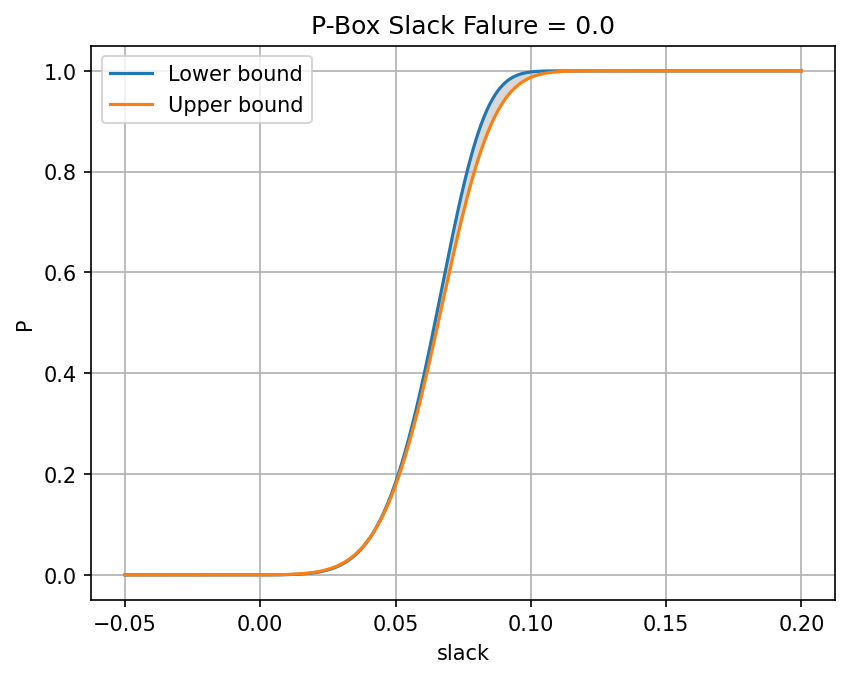

In [33]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_000, np.linspace(-0.05,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.0")

In [34]:
res_x_005, res_gld_005, res_fp_005 = pf_min_max_optimizer(0.05, result_dict, "experiment_slack005")

Maximization result:
  message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: -0.19955345287994547
       x: [ 2.220e-01  1.000e+00 ...  1.021e-01  1.000e+00]
     nit: 90
   maxcv: 3.833332414106619e-07
    nfev: 163
Minimization result:
  message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 0.07557494827971681
       x: [ 9.952e-01  1.459e-04 ...  9.952e-01  3.036e-04]
     nit: 137
   maxcv: 3.2347705831645146e-08
    nfev: 256


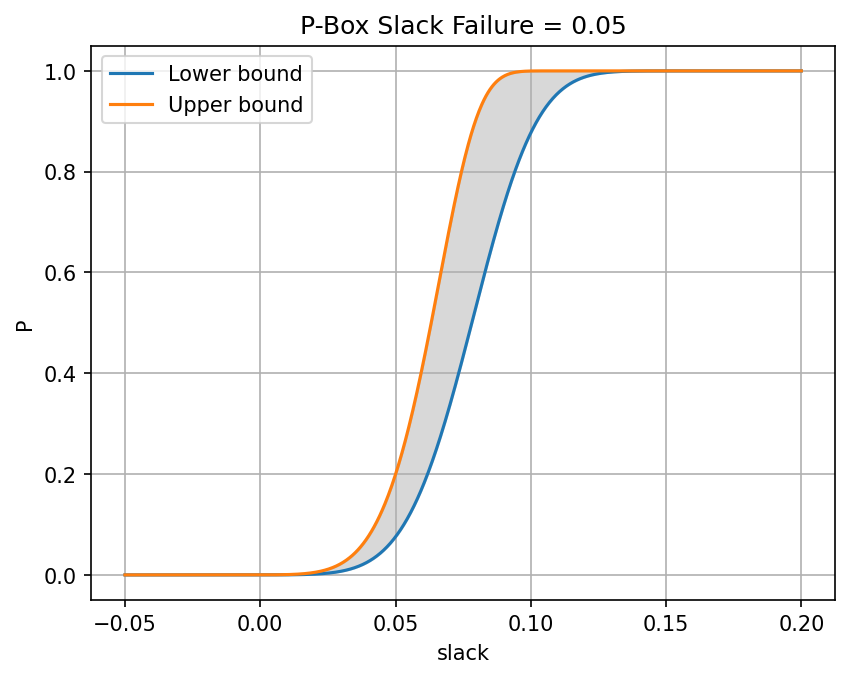

In [35]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_005, np.linspace(-0.05,0.2,1000), xlabel="slack", title="P-Box Slack Failure = 0.05")

In [36]:
res_gld_005

(array([0.079144  , 0.02645318, 0.47288281, 0.14269535]),
 array([0.06716671, 0.02027799, 0.35033438, 0.15967201]))

In [37]:
print(gld.CDF_num(0, res_gld_005[0]))
print(gld.CDF_num(0, res_gld_005[1]))

[0.00000964]
[0.00002525]


In [38]:
%matplotlib qt
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_005, np.linspace(-0.05,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.05")

Detected locale "LC_CTYPE=en_US.UTF-8;LC_NUMERIC=fr_FR.UTF-8;LC_TIME=fr_FR.UTF-8;LC_COLLATE=en_US.UTF-8;LC_MONETARY=fr_FR.UTF-8;LC_MESSAGES=en_US.UTF-8;LC_PAPER=fr_FR.UTF-8;LC_NAME=fr_FR.UTF-8;LC_ADDRESS=fr_FR.UTF-8;LC_TELEPHONE=fr_FR.UTF-8;LC_MEASUREMENT=fr_FR.UTF-8;LC_IDENTIFICATION=fr_FR.UTF-8" with character encoding "ANSI_X3.4-1968", which is not UTF-8.
Qt depends on a UTF-8 locale, and has switched to "en_US.UTF-8" instead.
If this causes problems, reconfigure your locale. See the locale(1) manual
for more information.
